# VLM Visual Question Answering with MATA

Demonstrates `VisionResult` auto-display for VLM (Visual Language Model)
tasks where the result carries a text answer alongside optional detected regions.

**Model used**: `Qwen/Qwen3-VL-2B-Instruct`

**Prerequisites**: `pip install datamata[notebook] transformers accelerate`

In [1]:
# !pip install datamata[notebook] transformers accelerate

In [2]:
import mata
print(f"MATA version: {mata.__version__}")

MATA version: 1.9.5


In [18]:
import os
from pathlib import Path

# Create a runs folder for saving outputs
runs_dir = Path("../..") / "runs" / "vlm"
runs_dir.mkdir(parents=True, exist_ok=True)

In [3]:
# Load a VLM
vlm = mata.load("vlm", "Qwen/Qwen3-VL-2B-Instruct")

[INFO] Loading vlm model from huggingface: Qwen/Qwen3-VL-2B-Instruct
[INFO] Auto-selected CUDA device (NVIDIA GeForce RTX 3070)
[INFO] Initialized HuggingFaceVLMAdapter with device=cuda, threshold=0.3
[INFO] Loading VLM model: Qwen/Qwen3-VL-2B-Instruct
[INFO] Loaded VLM model: Qwen/Qwen3-VL-2B-Instruct on cuda


In [4]:
IMAGE = "../../examples/images/000000039769.jpg"

result = vlm.predict(IMAGE, prompt="Describe what you see in this image.")

# Auto-display: shows VLM text answer + any detected instances
result

Label,Score,BBox


In [5]:
# Access the raw answer text
print(result.text)

This is a photograph of two cats resting on a bright pink couch. The scene is calm and peaceful, with the cats appearing to be sleeping or dozing.

- **The Cats**: There are two cats, both with tabby patterns. The cat on the left has a black and brown tabby coat with a green collar. It is lying on its back, with its paws stretched out and its eyes closed. The cat on the right has a lighter, more orange and brown tabby coat. It is lying on its side, with its head turned slightly to the side and its eyes closed. Both cats have their fur looking soft and fluffy.

- **The Couch**: The cats are lying on a vibrant pink couch. The couch has a smooth, possibly fabric, surface.

- **Remote Controls**: There are two remote controls on the couch. The one on the left is a white remote control with a green button on the side. The one on the right is a white remote control with a blue button on the side. The remote controls are positioned near the cats, one on the left and one on the right.

The ove

In [6]:
# Ask a specific question
result2 = vlm.predict(IMAGE, prompt="How many cats are in this image?")
result2

Label,Score,BBox


In [7]:
# Access the raw answer text
print(result.text)

This is a photograph of two cats resting on a bright pink couch. The scene is calm and peaceful, with the cats appearing to be sleeping or dozing.

- **The Cats**: There are two cats, both with tabby patterns. The cat on the left has a black and brown tabby coat with a green collar. It is lying on its back, with its paws stretched out and its eyes closed. The cat on the right has a lighter, more orange and brown tabby coat. It is lying on its side, with its head turned slightly to the side and its eyes closed. Both cats have their fur looking soft and fluffy.

- **The Couch**: The cats are lying on a vibrant pink couch. The couch has a smooth, possibly fabric, surface.

- **Remote Controls**: There are two remote controls on the couch. The one on the left is a white remote control with a green button on the side. The one on the right is a white remote control with a blue button on the side. The remote controls are positioned near the cats, one on the left and one on the right.

The ove

In [ ]:
# Uncomment the following lines to free up GPU memory after running the notebook

#del vlm
#import gc
#gc.collect()

#import torch
#torch.cuda.empty_cache()

We use **output_mode="detect"** to get bounding boxes for detected regions and use **auto_promote=True** to get a VisionResult that can be displayed with bounding boxes.

In [29]:
result = mata.run(
        "vlm",
        str(IMAGE),
        model="Qwen/Qwen3-VL-2B-Instruct",
        prompt="List all objects you can identify in this image.",
        output_mode="detect",
        auto_promote=True,  # promote entities with bbox -> Instance objects
        max_new_tokens=300,
    )

print(f"Raw response:\n{result.text}")
print(f"\nParsed entities: {len(result.entities)}")
print(f"Promoted instances (with bbox): {len(result.instances)}")


[INFO] Loading vlm model from huggingface: Qwen/Qwen3-VL-2B-Instruct
[INFO] Auto-selected CUDA device (NVIDIA GeForce RTX 3070)
[INFO] Initialized HuggingFaceVLMAdapter with device=cuda, threshold=0.3
[INFO] Loading VLM model: Qwen/Qwen3-VL-2B-Instruct
[INFO] Loaded VLM model: Qwen/Qwen3-VL-2B-Instruct on cuda
[INFO] Parsed 4 instances and 0 entities from VLM output (mode=detect, auto_promote=True)
Raw response:
```json
[
  {"label": "cat", "confidence": 0.96, "bbox": [535, 54, 1000, 771]},
  {"label": "cat", "confidence": 0.96, "bbox": [15, 108, 491, 985]},
  {"label": "remote", "confidence": 0.94, "bbox": [520, 158, 584, 384]},
  {"label": "remote", "confidence": 0.93, "bbox": [65, 149, 273, 244]}
]
```

Parsed entities: 0
Promoted instances (with bbox): 4


In [30]:
result

Label,Score,BBox
cat,0.960,"(342, 26, 640, 370)"
cat,0.960,"(10, 52, 314, 473)"
remote,0.940,"(333, 76, 374, 184)"
remote,0.930,"(42, 72, 175, 117)"


Label,Score,BBox
cat,0.960,"(342, 26, 640, 370)"
cat,0.960,"(10, 52, 314, 473)"
remote,0.940,"(333, 76, 374, 184)"
remote,0.930,"(42, 72, 175, 117)"

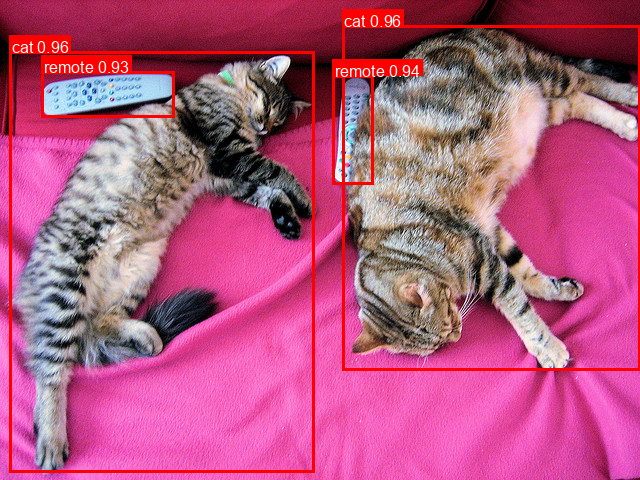

Saved to: ..\..\runs\vlm\vlm_output.png


In [33]:
# Save and display with bounding box overlays
output_path = runs_dir / "vlm_output.png"
mata.show(result, image=IMAGE, save=str(output_path))
print(f"Saved to: {output_path}")


## Notes

- `result.text` contains the VLM's free-form text answer
- If the VLM also returns bounding boxes (grounding), they appear in the instance table
- Medical / domain-specific VLMs: `mata.load("vlm", "google/medgemma-1.5-4b-it", dtype="bfloat16")`